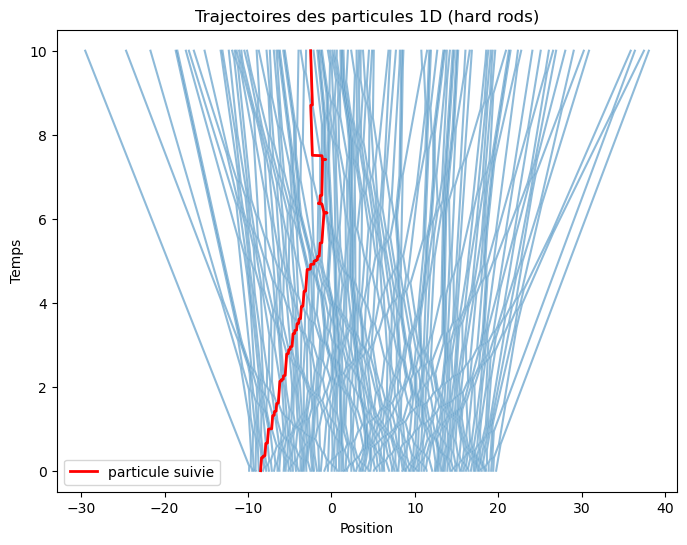

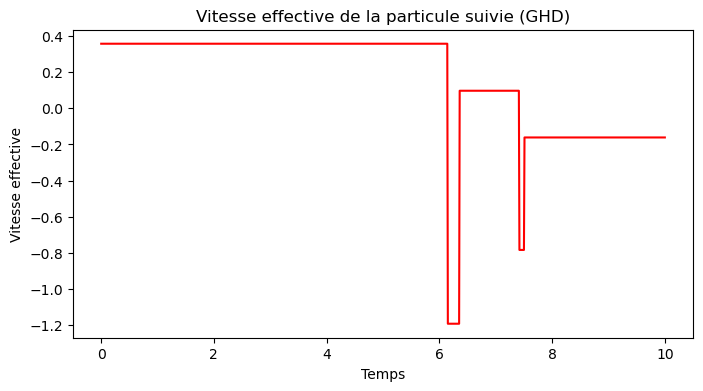

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
N = 100             # nombre de particules
L = 10.0           # longueur de la boîte
Delta = 0.2        # diamètre des particules
t_max = 10.0       # temps maximum
dt = 0.01          # pas de temps pour tracer
np.random.seed(42)

# Positions et vitesses initiales
x = np.sort(np.random.rand(N) * (L - N*Delta))  # position initiale
x += np.arange(N) * Delta                        # éviter chevauchement
v = np.random.randn(N)                           # vitesses initiales

# Pour la particule suivie
tracked = 5   # index de la particule suivie
v_eff = [v[tracked]]  # vitesse effective de cette particule
x_eff = [x[tracked]]  # position effective

# Stockage des trajectoires pour le plot
trajectories = np.zeros((N, int(t_max/dt)+1))
trajectories[:,0] = x

time = 0.0
for n in range(1, int(t_max/dt)+1):
    # Déplacement simple
    x += v * dt

    # Collision entre particules (hard rod)
    for i in range(N-1):
        if x[i+1] - x[i] < Delta:
            # Échange des vitesses
            v[i], v[i+1] = v[i+1], v[i]
            if tracked == i : tracked = i+1
            elif tracked == i +1  : tracked = i-1

    # Conditions périodiques
    #x = np.mod(x, L)

    # Mise à jour trajectoires
    trajectories[:,n] = x

    # Mise à jour particule suivie (vitesse "GHD")
    x_eff.append(x[tracked])
    v_eff.append(v[tracked])

# Temps pour l'axe y
t_array = np.linspace(0, t_max, int(t_max/dt)+1)

# Tracé espace-temps des particules
plt.figure(figsize=(8,6))
for i in range(N):
    plt.plot(trajectories[i,:], t_array, color='C0', alpha=0.5)
plt.plot(x_eff, t_array, color='red', lw=2, label="particule suivie")
plt.xlabel("Position")
plt.ylabel("Temps")
plt.title("Trajectoires des particules 1D (hard rods)")
plt.legend()
plt.show()

# Tracé vitesse effective de la particule suivie
plt.figure(figsize=(8,4))
plt.plot(t_array, v_eff, color='red')
plt.xlabel("Temps")
plt.ylabel("Vitesse effective")
plt.title("Vitesse effective de la particule suivie (GHD)")
plt.show()


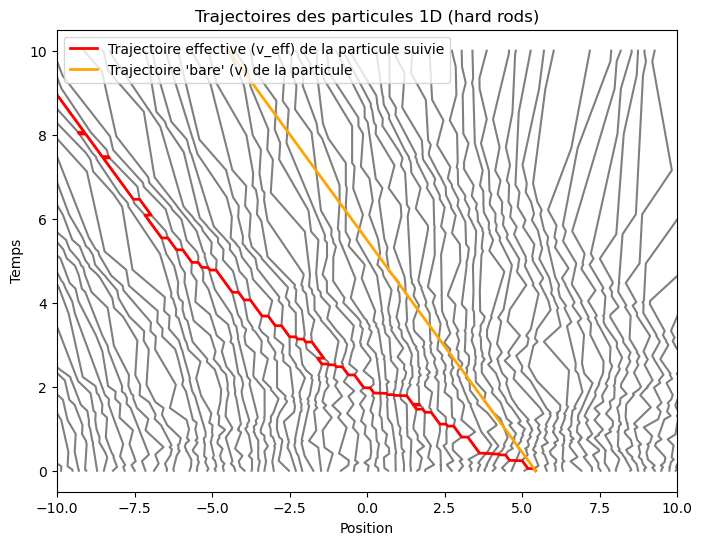

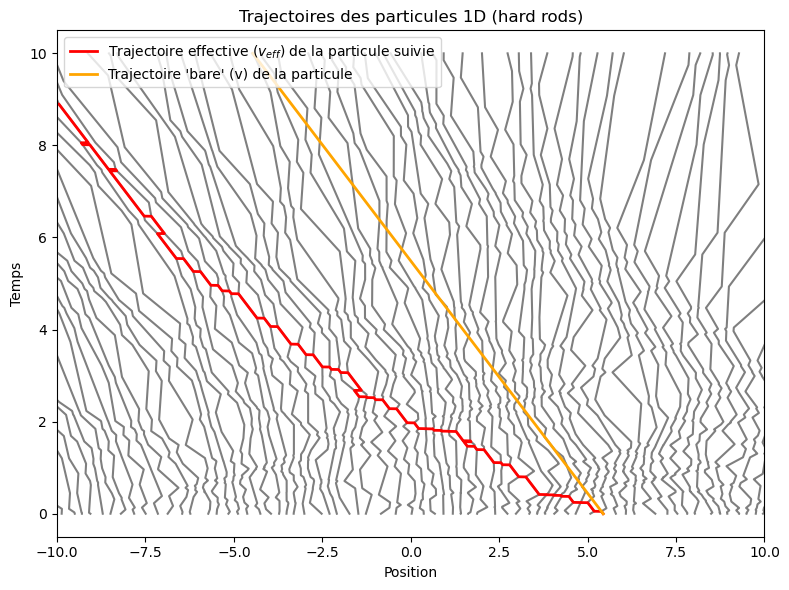

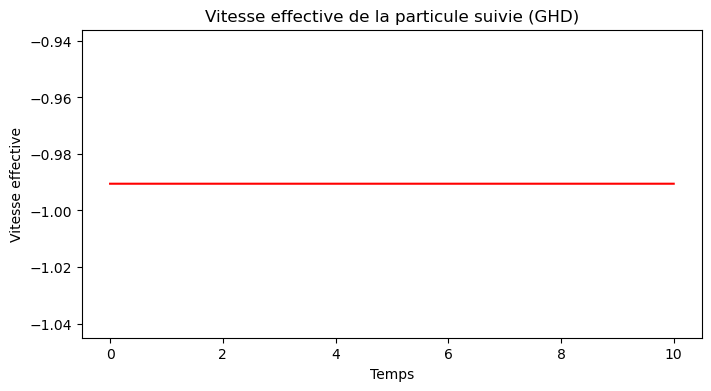

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
N = 100             # nombre de particules
L = 10.0            # longueur de la boîte
Delta = 0.2         # diamètre des particules
t_max = 10.0        # temps maximum
dt = 0.001           # pas de temps pour tracer
np.random.seed(42)

# Positions et vitesses initiales
x = np.sort(np.random.rand(N) * (L - N*Delta))  # positions initiales
x += np.arange(N) * Delta                        # éviter chevauchement
v = np.random.randn(N)                           # vitesses initiales

# Particule suivie
tracked = int(N/2)           # index fixe de la particule suivie
v_eff = [v[tracked]]  # vitesse effective
x_eff = [x[tracked]]  # position effective

# Stockage trajectoires
trajectories = np.zeros((N, int(t_max/dt)+1))
trajectories[:,0] = x

for n in range(1, int(t_max/dt)+1):
    # Déplacement
    x += v * dt

    # Collision hard rods
    for i in range(N-1):
        if x[i+1] - x[i] < Delta:
            # Échange des vitesses
            v[i], v[i+1] = v[i+1], v[i]
    tracked = np.where(v == v_eff[0])[0]

    # Conditions périodiques (optionnel)
    # x = np.mod(x, L)
    
    # Stockage trajectoires
    trajectories[:,n] = x

    # Mise à jour particule suivie
    x_eff.append(x[tracked][0])
    v_eff.append(v[tracked][0])

# Axe temps
t_array = np.linspace(0, t_max, int(t_max/dt)+1)

# Tracé espace-temps
plt.figure(figsize=(8,6))
for i in range(N):
    plt.plot(trajectories[i,:], t_array, color='k', alpha=0.5)

plt.plot(x_eff, t_array, color='red', lw=2, label="Trajectoire effective (v_eff) de la particule suivie")
plt.plot([x_eff[0], x_eff[0] + v_eff[0]*t_max], [0, t_max], color='orange', lw=2, label="Trajectoire 'bare' (v) de la particule")

plt.xlabel("Position")
plt.ylabel("Temps")
plt.xlim(-L, L) 
plt.title("Trajectoires des particules 1D (hard rods)")
plt.legend()
plt.show()

    # Tracé espace-temps
plt.figure(figsize=(8,6))
for i in range(N):
    plt.plot(trajectories[i,:], t_array, color='k', alpha=0.5)

plt.plot(x_eff, t_array, color='red', lw=2, label="Trajectoire effective ($v_{eff}$) de la particule suivie")
plt.plot([x_eff[0], x_eff[0] + v_eff[0]*t_max], [0, t_max], color='orange', lw=2, label="Trajectoire 'bare' (v) de la particule")

plt.xlabel("Position")
plt.ylabel("Temps")
plt.xlim(-L, L) 
plt.title("Trajectoires des particules 1D (hard rods)")
plt.legend()
plt.tight_layout()

# Sauvegarde
plt.savefig("trajectoires_hard_rods.png", dpi=300)
plt.show()

# Tracé vitesse effective
plt.figure(figsize=(8,4))
plt.plot(t_array, v_eff, color='red')
plt.xlabel("Temps")
plt.ylabel("Vitesse effective")
plt.title("Vitesse effective de la particule suivie (GHD)")
plt.show()


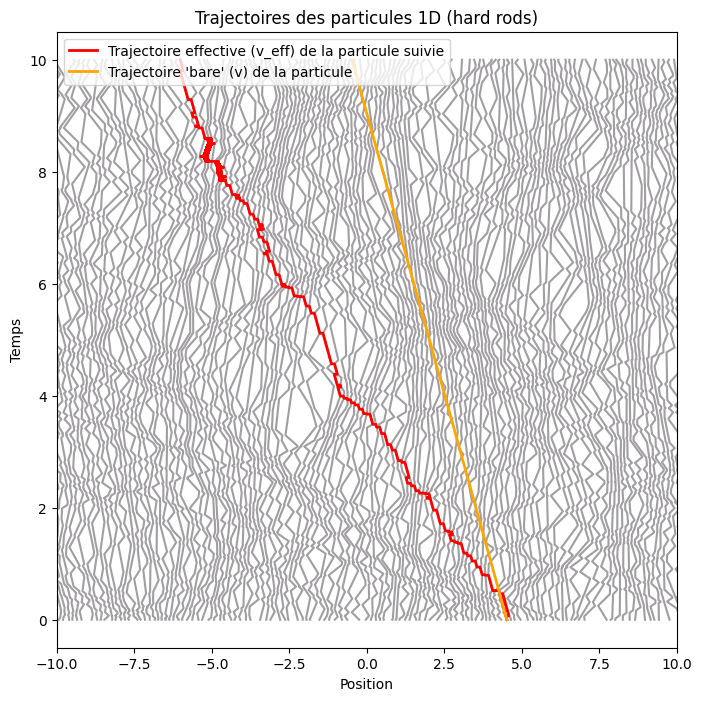

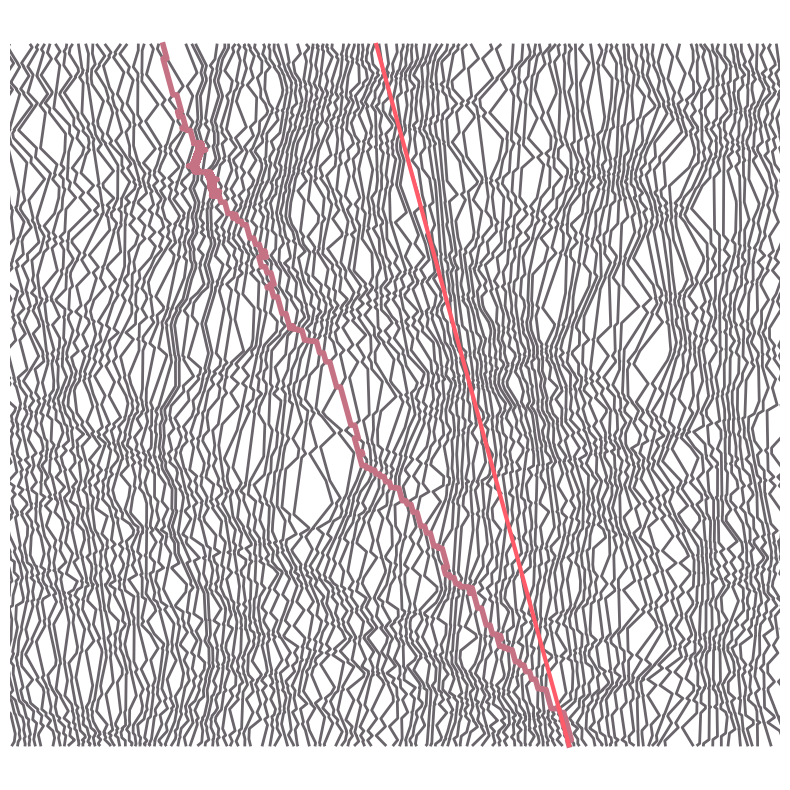

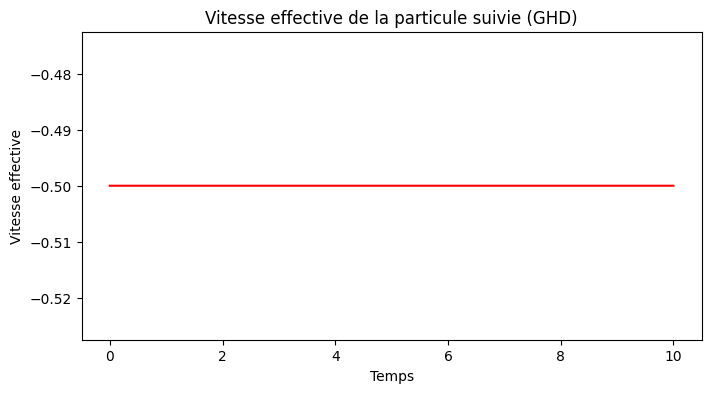

In [4]:
import numpy as np
import matplotlib.pyplot as plt

colorOne   = "#443E46"
colorTwo   = "#FFFFFF"  # blanc
colorThree = "#908CA4"
colorFour  = "#57659E"
colorFive  = "#C57284"
colorSix   = "#FF5B69"

# Paramètres
N = 500             # nombre de particules
L = 10.0            # longueur de la boîte
Delta = 0.1         # diamètre des particules
t_max = 10.0        # temps maximum
dt = 0.001           # pas de temps pour tracer
np.random.seed(42)

# Positions et vitesses initiales
x = np.sort(np.random.rand(N) * (L - N*Delta))  # positions initiales
x += np.arange(N) * Delta                        # éviter chevauchement
v = np.random.randn(N)                           # vitesses initiales


# Particule suivie
tracked = int(N/2)           # index fixe de la particule suivie
v[tracked] = -0.5
v_eff = [v[tracked]]  # vitesse effective
x_eff = [x[tracked]]  # position effective

# Stockage trajectoires
trajectories = np.zeros((N, int(t_max/dt)+1))
trajectories[:,0] = x

for n in range(1, int(t_max/dt)+1):
    # Déplacement
    x += v * dt

    # Collision hard rods
    for i in range(N-1):
        if x[i+1] - x[i] < Delta:
            # Échange des vitesses
            v[i], v[i+1] = v[i+1], v[i]
    tracked = np.where(v == v_eff[0])[0]

    # Conditions périodiques (optionnel)
    # x = np.mod(x, L)
    
    # Stockage trajectoires
    trajectories[:,n] = x

    # Mise à jour particule suivie
    x_eff.append(x[tracked][0])
    v_eff.append(v[tracked][0])

# Axe temps
t_array = np.linspace(0, t_max, int(t_max/dt)+1)

# Tracé espace-temps
plt.figure(figsize=(8,8))
for i in range(N):
    plt.plot(trajectories[i,:], t_array, color=colorOne , alpha=0.5)

plt.plot(x_eff, t_array, color='red', lw=2, label="Trajectoire effective (v_eff) de la particule suivie")
plt.plot([x_eff[0], x_eff[0] + v_eff[0]*t_max], [0, t_max], color='orange', lw=2, label="Trajectoire 'bare' (v) de la particule")

plt.xlabel("Position")
plt.ylabel("Temps")
plt.xlim(-L, L) 
plt.title("Trajectoires des particules 1D (hard rods)")
plt.legend()
plt.show()

    # Tracé espace-temps
plt.figure(figsize=(8,8))
for i in range(N):
    plt.plot(trajectories[i,:], t_array,  lw=2,  color=colorOne , alpha=0.8)

plt.plot(x_eff, t_array, color=colorFive , lw=4, label="Trajectoire effective ($v_{eff}$) de la particule suivie")
plt.plot([x_eff[0], x_eff[0] + v_eff[0]*t_max], [0, t_max], color=colorSix , lw=3, label="Trajectoire 'bare' (v) de la particule")

#plt.xlabel("Position")
#plt.ylabel("Temps")
plt.xlim(-L, L) 
#plt.title("Trajectoires des particules 1D (hard rods)")
#plt.legend()
plt.axis('off')  # masque tout le système d'axes
plt.tight_layout()

# Sauvegarde
plt.savefig("trajectoires_hard_rods.png", dpi=300)
plt.show()

# Tracé vitesse effective
plt.figure(figsize=(8,4))
plt.plot(t_array, v_eff, color='red')
plt.xlabel("Temps")
plt.ylabel("Vitesse effective")
plt.title("Vitesse effective de la particule suivie (GHD)")
plt.show()
